# ME144/244 Project 6: Modeling and Simulation of LiDAR Detection Systems

Run this notebook top-to-bottom to generate the true surfaces, reconstructed point clouds, and error values for all three amplitudes.

In [7]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from lidar.surfaces import surfG, gradG, A_
from lidar.simulation import lidarsim, animate_rays, error

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

print("Modules imported successfully!")
print(f"Surface amplitudes: {A_}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Modules imported successfully!
Surface amplitudes: [0.04, 0.16, 0.64]


## Verify Surface Functions

Equation (1) predicts `G(0, 0, A) = 2` and `\nabla G(0, 0, A) = [0, 0]` for any amplitude.

In [8]:
test_x = 0.0
test_y = 0.0

for test_A in A_:
    z_test = surfG(test_x, test_y, test_A)
    grad_test = gradG(test_x, test_y, test_A)
    print(f"A = {test_A:0.2f} -> G(0,0) = {z_test:.4f}, gradG(0,0) = [{grad_test[0]:.4f}, {grad_test[1]:.4f}]")

A = 0.04 -> G(0,0) = 2.0000, gradG(0,0) = [0.0000, 0.0000]
A = 0.16 -> G(0,0) = 2.0000, gradG(0,0) = [0.0000, 0.0000]
A = 0.64 -> G(0,0) = 2.0000, gradG(0,0) = [0.0000, 0.0000]


## True Surfaces

Plot and save the three true surfaces over the domain $x_1, x_2 \in [-0.5, 0.5]$.

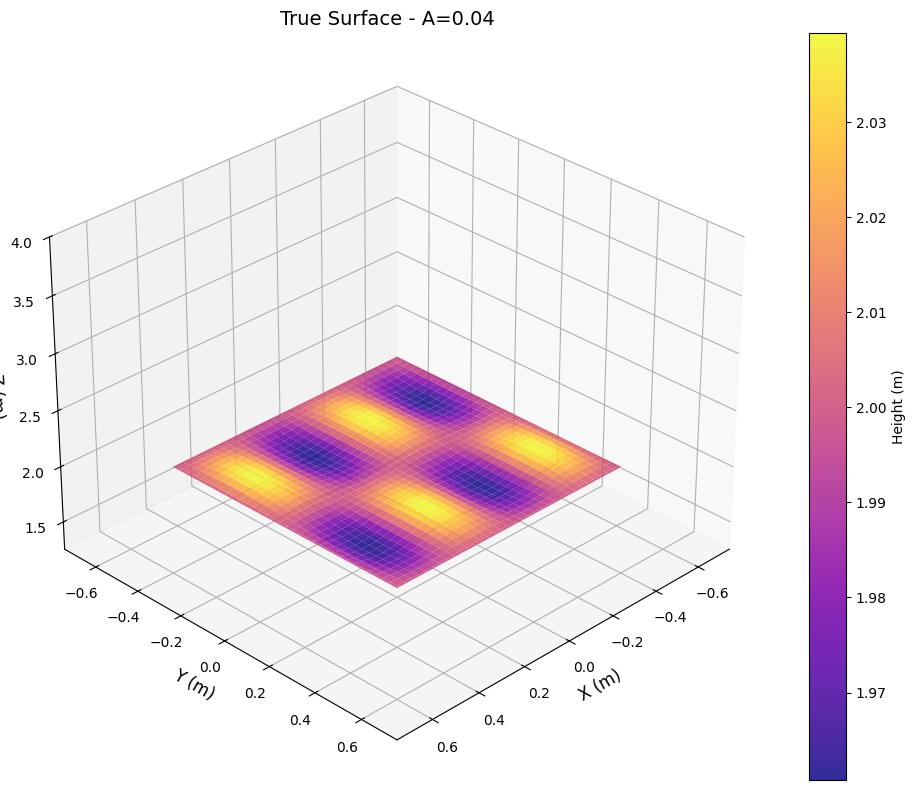

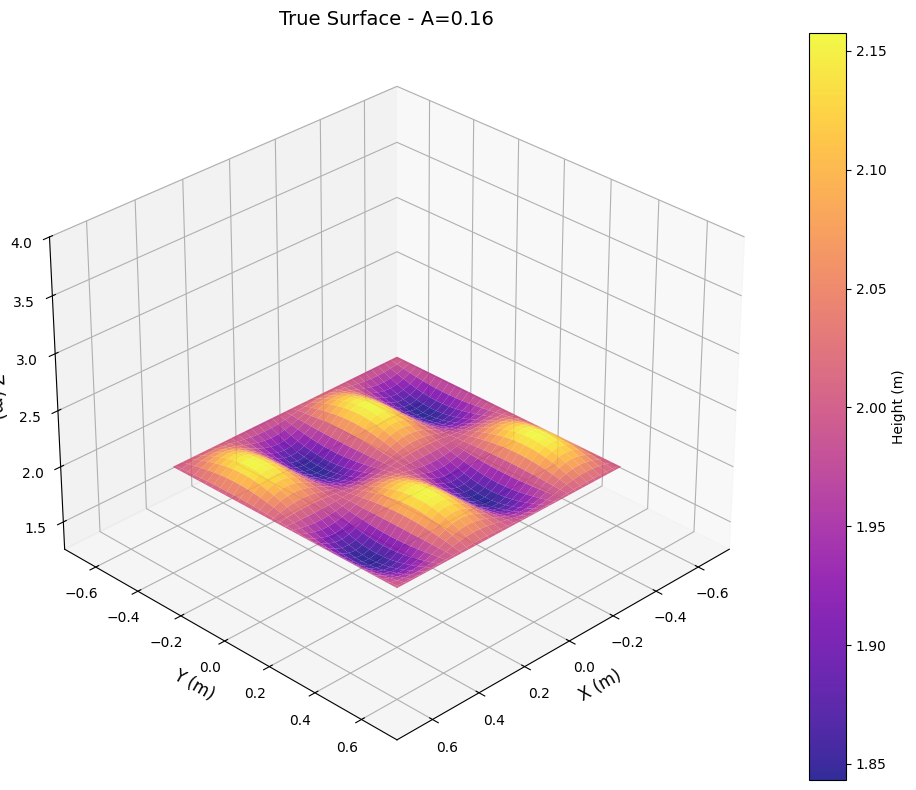

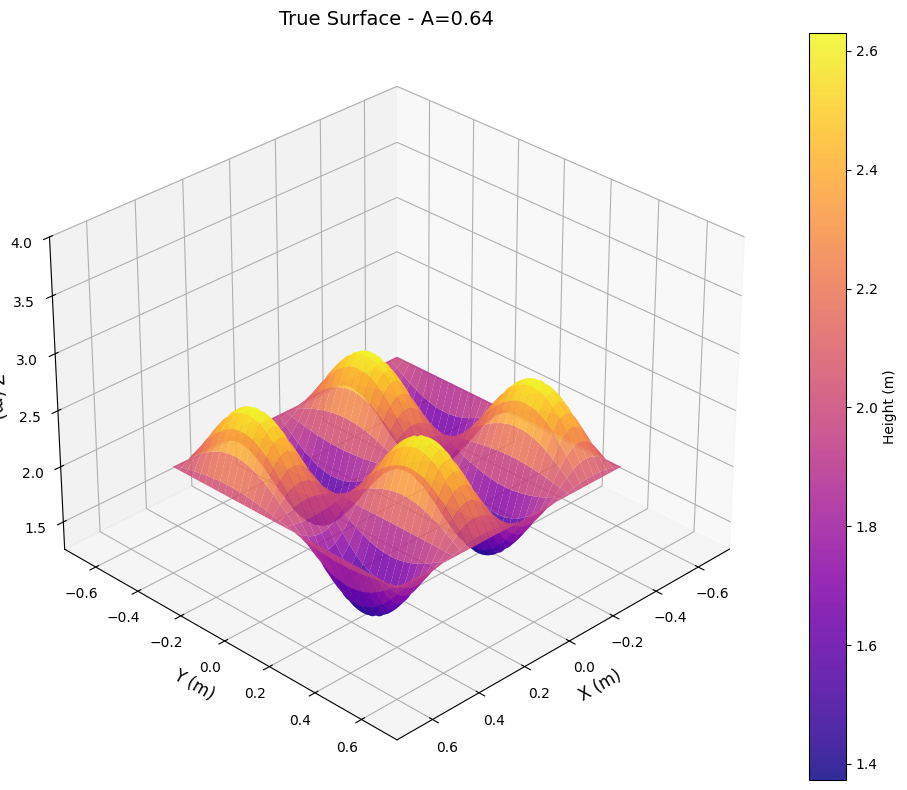

In [9]:
x = y = np.arange(-0.5, 0.5 + 0.01, 0.01)
X, Y = np.meshgrid(x, y)

for amplitude in A_:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    Z = surfG(X, Y, amplitude)
    surf = ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.85)

    ax.set_xlim(-0.75, 0.75)
    ax.set_ylim(-0.75, 0.75)
    ax.set_zlim(1.25, 4.0)
    ax.set_xlabel('X (m)', fontsize=12)
    ax.set_ylabel('Y (m)', fontsize=12)
    ax.set_zlabel('Z (m)', fontsize=12)
    ax.set_title(f'True Surface - A={amplitude}', fontsize=14)
    ax.view_init(elev=30.0, azim=45)

    fig.colorbar(surf, ax=ax, label='Height (m)')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'surfacePlot_A{amplitude}.png', dpi=200)
    plt.show()

## Run Simulations

Execute the LiDAR simulation for each amplitude and collect the animation trajectories.

Starting LIDAR Simulations

Running simulation for surface 1 of 3
Surface amplitude A = 0.04


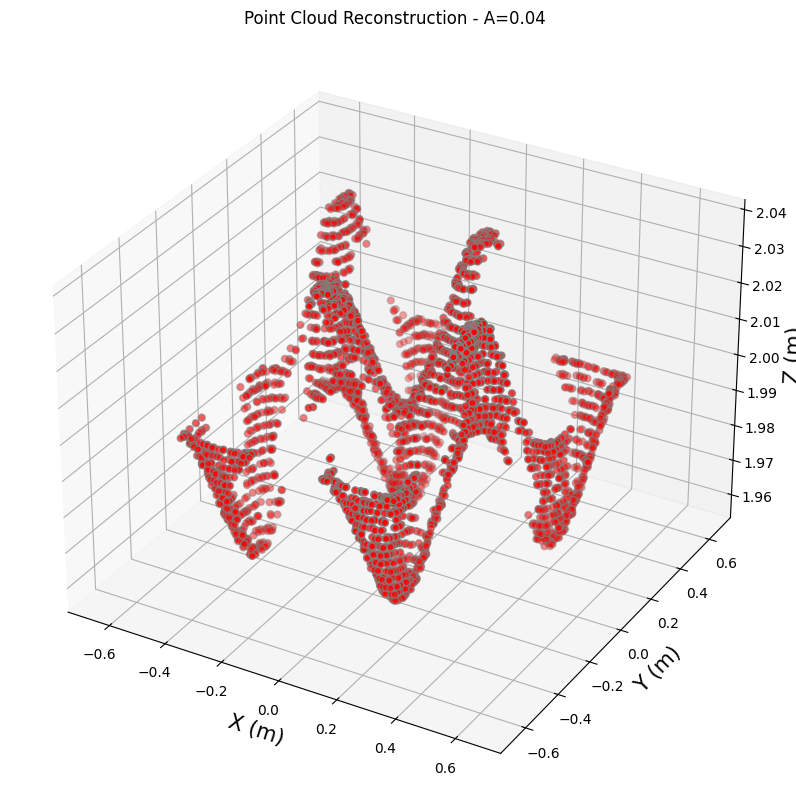

Finished -> Error =  0.5865

Running simulation for surface 2 of 3
Surface amplitude A = 0.16


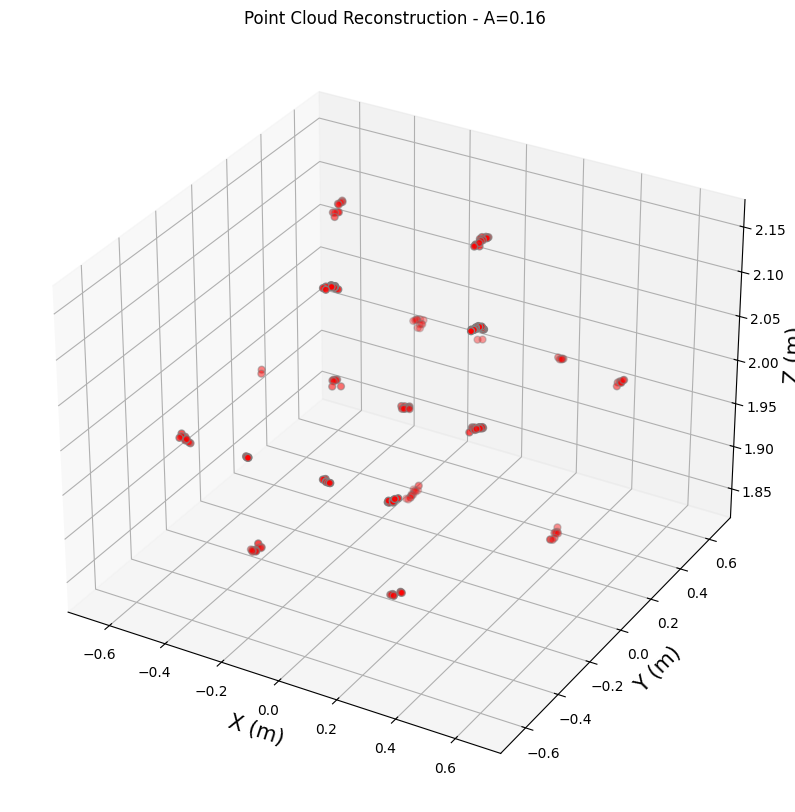

Finished -> Error =  0.9792

Running simulation for surface 3 of 3
Surface amplitude A = 0.64


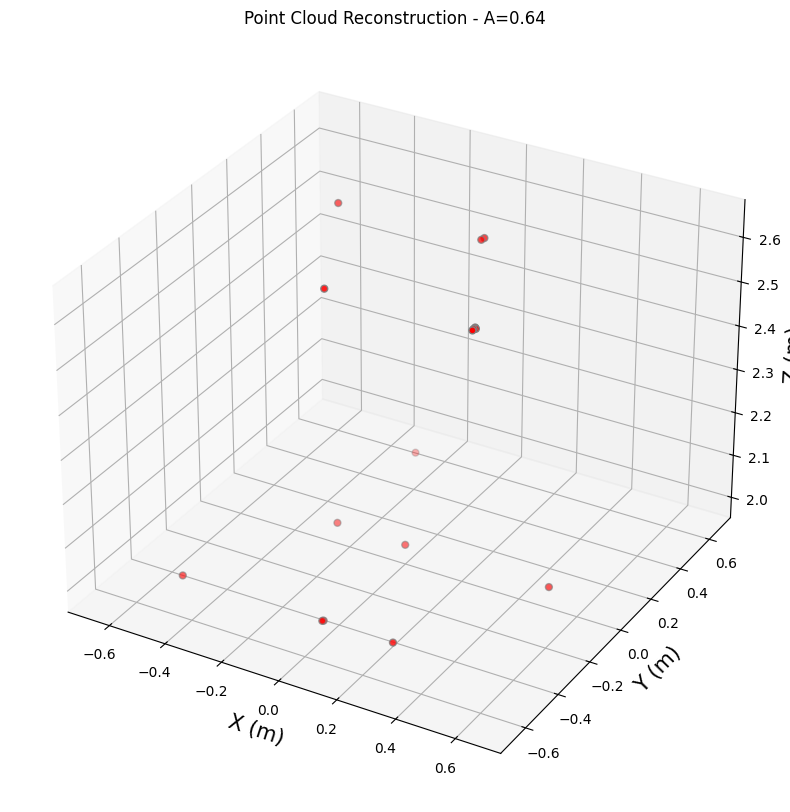

Finished -> Error =  0.9984

All simulations completed!


In [10]:
print("=" * 70)
print("Starting LIDAR Simulations")
print("=" * 70)

simulation_results = []

for surface_idx, amplitude in enumerate(A_):
    print(f"\nRunning simulation for surface {surface_idx + 1} of {len(A_)}")
    print(f"Surface amplitude A = {amplitude}")
    posTot = lidarsim(surface_idx)
    simulation_results.append({
        'amplitude': amplitude,
        'surface_idx': surface_idx,
        'posTot': posTot,
        'error': error[surface_idx],
    })

print("\n" + "=" * 70)
print("All simulations completed!")

## Error Summary

In [11]:
print("Amplitude    Reconstruction Error")
print("-" * 34)
for result in simulation_results:
    print(f"{result['amplitude']:>8.2f}    {result['error']:.6f}")

Amplitude    Reconstruction Error
----------------------------------
    0.04    0.586500
    0.16    0.979200
    0.64    0.998400


## Optional Animation

Display one animation for debugging or visualization.

In [12]:
surface_to_animate = 1
max_frames = 100

print(f"Creating animation for surface {surface_to_animate} (A = {A_[surface_to_animate]})")

posTot = simulation_results[surface_to_animate]['posTot']
display(animate_rays(posTot[:max_frames], surface_to_animate))

Creating animation for surface 1 (A = 0.16)
